[28654.98185996 19522.39268679 10131.15848557 13100.7680182
 27366.95435767  5607.0605958   8031.78102046  6383.53187258
  9416.04842321  8446.30254039 13504.36329611  6252.68029646
 17959.31442838  8647.79134229 43948.64429505  5685.47088599
  4320.37319775 13915.15199199 10349.30455642 10571.50282498
 11760.49509927 16629.10974422  5105.52202533  3530.51484358
  8056.00873302 28862.67985298 11602.81521233 16533.80922306
  4648.57428588 17188.12496646 27354.98697165  5727.17836592
  5718.40819974 18334.07413679  7365.96625357 25186.86411177
 12949.67875409 12758.1941218   7399.60841689 14345.81703038
  6725.54920057]
Mean Squared Error: 7852574.20381778
R-squared: 0.9005298423323502


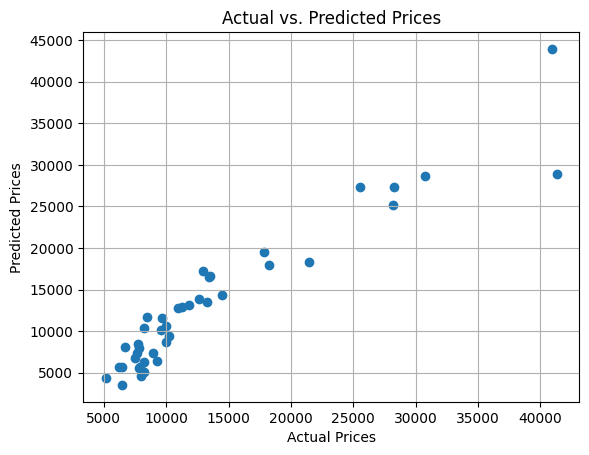

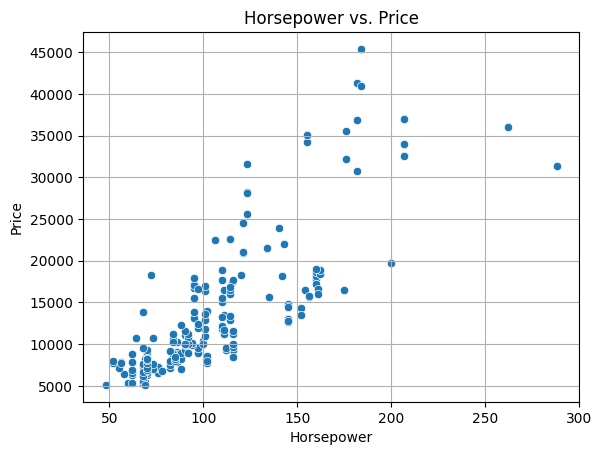

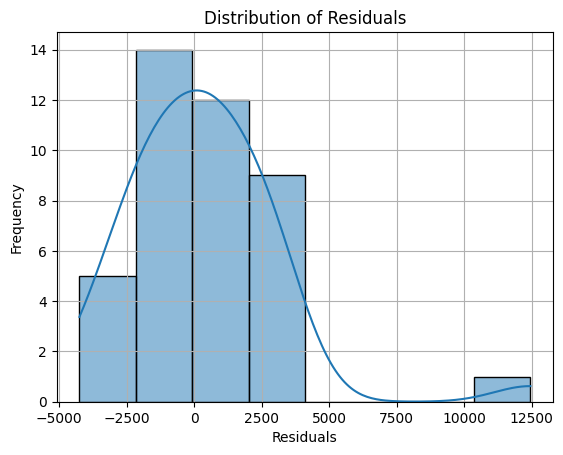

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

carData = pd.read_csv('CarPrice.csv')

# Drop the CarName column
carData = carData.drop('CarName', axis=1)

# Convert categorical columns to numerical using one-hot encoding
carData = pd.get_dummies(carData, columns=['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem'], drop_first=True)


X = carData.drop('price', axis=1)
y = carData['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted Prices")
plt.grid(True)
plt.show()


sns.scatterplot(x='horsepower', y='price', data=carData)
plt.xlabel("Horsepower")
plt.ylabel("Price")
plt.title("Horsepower vs. Price")
plt.grid(True)
plt.show()

sns.histplot(y_test - y_pred, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.grid(True)
plt.show()

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 226592896.0000
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 201497696.0000 
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 230743696.0000 
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 258146496.0000 
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 237074752.0000 
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 230288480.0000 
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 224281344.0000 
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 235650048.0000 
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 231890960.0000 
Epoch 10/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 245685104.0000 
Epoch 11/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 226487232.0000 
Epoch 12/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 251469072.0000 
Epoch 13/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 236522000.0000  
Epoch 14/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2

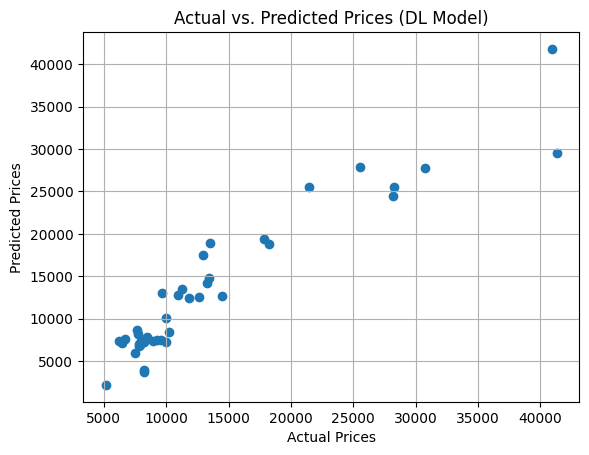

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

dl_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # Add a single output neuron for regression
])

dl_model.compile(optimizer='adam', loss='mean_squared_error')
dl_model.fit(X_train, y_train, epochs=100, batch_size=32) # Remove validation_split

y_dl_model = dl_model.predict(X_test).flatten()

mse_dl_model = mean_squared_error(y_test, y_dl_model)
r2_dl_model = r2_score(y_test, y_dl_model)

print("Mean Squared Error (DL Model):", mse_dl_model)
print("R-squared (DL Model):", r2_dl_model)


plt.scatter(y_test, y_dl_model)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted Prices (DL Model)")
plt.grid(True)
plt.show()